## 1. What this notebook computes

The first of Sakharov's three conditions for making more matter than antimatter
is that some process must **change** the number that counts matter minus
antimatter. The theory of this book contains no baryons; the only number of this
kind it has is the **U(1) charge** $Q$ of the field: the Lagrangian does not
change when the field is
multiplied by a constant phase $e^{i\alpha}$, and by Noether's theorem the charge
of this symmetry obeys a **local** conservation law: no process creates or
destroys it at any point of the patch $0 < z < \pi/2$ (off the brane), and the
charge of a region changes only by what flows through its boundary. This
notebook checks that law exactly in
the author's primordial metric, for **every** history $a_4(x_4)$, in particular
the one in which ordinary space inflates and the three extra times deflate
exponentially. It

1. builds the canonical spin connection of the author's metric with sympy and
   checks that it is real and gives $\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$;
2. reduces the conservation law $\partial_\mu(\cos z\,J^\mu) = 0$ (on solutions)
   to one $16 \times 16$ matrix identity and verifies it exactly, with a negative
   control (no spin connection: the identity fails) and a control metric (the
   extra times inflating too), which shows **why** the time-derivative terms
   cancel: the deflation of the extra times keeps the volume of a slice constant;
3. checks the Noether current by changing the phase of a field from point to
   point;
4. follows the charge of an **exact solution** of the field equation in the
   author's metric: local conservation (exact, and a finite-difference test), the
   charge balance with the flux through the brane $z = \pi/2$, and a solution
   whose flux vanishes, so that its charge stays constant while the extra times
   deflate;
5. shows that the charge density $\Psi^\dagger B\Psi$ can be positive or negative;
6. does the **pair-level bookkeeping** of theorem T1: the chirality partner
   $\Gamma\Psi$ (a solution with the mass reversed) carries exactly the opposite
   current, so a pair has total charge zero.

Two checks reproduce `Revision/lead_checks/reports/charge-conjugation-and-u1.json`;
others reproduce the Revision field-theory and pairing records. Eight plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 21b (Local U(1) charge conservation, the brane flux and the pair-level charge
bookkeeping) is the file `Revision/textbook/notebooks/21b_charge_conservation.ipynb` of
the repository Dirac_claude. It builds the canonical spin connection of the author's
metric for a general history a4(x4) with sympy, checks that it is real, reduces the U(1)
Noether identity to a 16 by 16 matrix identity and verifies it exactly (with a negative
control without the spin connection and a control metric with inflating extra times,
which shows that the a4 terms cancel because the deflating extra times keep the volume of
a slice constant), checks the Noether current by a local phase change, follows the charge
of an exact solution of the field equation in the author's metric (exact local
conservation, second-order convergence of a finite-difference test, the charge balance
with the flux through the brane, a solution with zero flux and constant charge), shows
that the charge density is indefinite, and does the pair-level bookkeeping of theorem T1:
the chirality partner carries the opposite current, so the total charge of a pair is
zero. Eight teaching plots. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 21b_charge_conservation.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 40 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 21b_charge_conservation.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
21b_charge_conservation.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/21b.captions.json`
- `Revision/textbook/figures/21b_1_volume_balance.png`
- `Revision/textbook/figures/21b_2_noether_matrices.png`
- `Revision/textbook/figures/21b_3_charge_density_maps.png`
- `Revision/textbook/figures/21b_4_charge_balance.png`
- `Revision/textbook/figures/21b_5_local_conservation.png`
- `Revision/textbook/figures/21b_6_charge_through_deflation.png`
- `Revision/textbook/figures/21b_7_indefinite_charge.png`
- `Revision/textbook/figures/21b_8_pair_bookkeeping.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the eight figure files of notebook 21b exist
    ALL 21 CHECKS PASSED (notebook 21b)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/21b_charge_conservation.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 21b_charge_conservation.ipynb
      python -m nbconvert --execute --inplace 21b_charge_conservation.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file in the folder `Revision/algebra`, `Revision/theory`,
  `Revision/pairing` or `Revision/lead_checks`: the notebook was opened outside the
  repository, or the repository is incomplete; clone the repository again and open the
  notebook from its folder `Revision/textbook/notebooks`.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 21b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 21b (Local U(1) charge conservation, the brane flux and the pair-level charge
# bookkeeping) is the file Revision/textbook/notebooks/21b_charge_conservation.ipynb of
# the repository Dirac_claude. It builds the canonical spin connection of the author's
# metric for a general history a4(x4) with sympy, checks that it is real, reduces the
# U(1) Noether identity to a 16 by 16 matrix identity and verifies it exactly (with a
# negative control without the spin connection and a control metric with inflating extra
# times, which shows that the a4 terms cancel because the deflating extra times keep the
# volume of a slice constant), checks the Noether current by a local phase change,
# follows the charge of an exact solution of the field equation in the author's metric
# (exact local conservation, second-order convergence of a finite-difference test, the
# charge balance with the flux through the brane, a solution with zero flux and constant
# charge), shows that the charge density is indefinite, and does the pair-level
# bookkeeping of theorem T1: the chirality partner carries the opposite current, so the
# total charge of a pair is zero. Eight teaching plots. It needs a computer with Windows
# 11, macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 21b_charge_conservation.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 40
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 21b_charge_conservation.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 21b_charge_conservation.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/21b.captions.json
# - Revision/textbook/figures/21b_1_volume_balance.png
# - Revision/textbook/figures/21b_2_noether_matrices.png
# - Revision/textbook/figures/21b_3_charge_density_maps.png
# - Revision/textbook/figures/21b_4_charge_balance.png
# - Revision/textbook/figures/21b_5_local_conservation.png
# - Revision/textbook/figures/21b_6_charge_through_deflation.png
# - Revision/textbook/figures/21b_7_indefinite_charge.png
# - Revision/textbook/figures/21b_8_pair_bookkeeping.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the eight figure files of notebook 21b exist
#     ALL 21 CHECKS PASSED (notebook 21b)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/21b_charge_conservation.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 21b_charge_conservation.ipynb
#     python -m nbconvert --execute --inplace 21b_charge_conservation.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file in the folder Revision/algebra, Revision/theory,
#   Revision/pairing or Revision/lead_checks: the notebook was opened outside the
#   repository, or the repository is incomplete; clone the repository again and open the
#   notebook from its folder Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "21b"  # this notebook: chapter 21, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 21b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Phase**: a complex number $e^{i\alpha} = \cos\alpha + i\sin\alpha$ of modulus
  1. Multiplying every component of $\Psi$ by the same $e^{i\alpha}$ is a
  **global U(1) transformation** (U(1) is the name of the group of these phases).
- **Symmetry, Noether's theorem**: when the Lagrangian does not change under a
  continuous transformation, there is a **current** $J^\mu$ whose divergence
  vanishes on every solution (a **local** conservation law); its time component
  integrated over space is the **charge** $Q$, which changes only by what flows
  through the boundary of the region (it is constant when nothing flows
  through it).
- **Current** $J^\mu = -i\bar\Psi\gamma^\mu\Psi$ (eight components, $\mu = x1,
  \dots, x8$), with $\bar\Psi = \Psi^\dagger C$ and the curved gammas
  $\gamma^\mu = e^\mu{}_a\gamma^a$; its time component is the **charge density**
  $J^{(x4)} = \Psi^\dagger B\Psi$, $B = -iC\gamma^{(x4)}$.
- **Divergence** $\partial_\mu(\cos z\,J^\mu) = \sum_\mu \partial(\cos z\,J^\mu)
  /\partial x_\mu$; $\cos z = \sqrt{|g|}$ is the volume factor of the author's
  metric.
- **Flux**: the amount of charge that flows through a surface per unit time;
  **charge balance**: the charge inside a region changes exactly by the flux
  through its boundary.
- **Vielbein** $e^a{}_\mu$: the eight scale factors $f_a$ of the author's metric,
  $f_{1,2,3} = e^{a_4}\sin^{1/6}z$ (ordinary space), $f_4 = 1$ (the time),
  $f_{5,6,7} = e^{-a_4}\sin^{1/6}z$ (the deflating extra times), $f_8 = \cot z$
  (the hidden direction), with $z = 6Hx_8$.
- **Spin connection** $\Omega_\mu = \tfrac12\omega_{\mu ab}S^{ab}$: the matrices
  that make the derivative $D_\mu = \partial_\mu + \Omega_\mu$ of a spinor
  covariant; $\omega_{\mu ab}$ are built from the vielbein and the Christoffel
  symbols, and $S^{ab} = \tfrac14[\gamma^a, \gamma^b]$.
- **Brane**: the end $z = \pi/2$ of the patch $0 < z < \pi/2$ of the hidden
  direction.
- **Chirality partner**: $\Gamma\Psi$ with $\Gamma = \gamma^{(x8)}\gamma^{(x1)}
  \cdots\gamma^{(x7)}$; by theorem T1 of the Revision pairing record it solves the
  field equation with the mass reversed.
- **Indefinite**: a quadratic expression that can take both signs.

## 4. The physical and mathematical situation

**The symmetry.** The Lagrangian of both fields of the Revision record is
$\mathcal{L} = \cos z\,[\tfrac12(\bar\Psi\gamma^\mu D_\mu\Psi - (D_\mu\bar\Psi)
\gamma^\mu\Psi) - mS - U(S)]$ with $S = \bar\Psi\Psi$. Under $\Psi \to
e^{i\alpha}\Psi$ with a constant $\alpha$, $\Psi^\dagger \to e^{-i\alpha}
\Psi^\dagger$, so every bilinear $\Psi^\dagger X\Psi$ is multiplied by
$e^{-i\alpha}e^{i\alpha} = 1$: $\mathcal{L}$ does not change.

**The identity behind conservation**, line by line. Write the current as
$J^\mu = \Psi^\dagger K^\mu\Psi$ with $K^\mu = -iC\gamma^\mu$, and the field
equation as $E = \gamma^\mu D_\mu\Psi - V\Psi = 0$ with real $V = m + U'(S)$.

1. Product rule: $\partial_\mu(\cos z\,J^\mu) = \Psi^\dagger[\partial_\mu(\cos z
   \,K^\mu)]\Psi + \cos z\,[(\partial_\mu\Psi)^\dagger K^\mu\Psi + \Psi^\dagger
   K^\mu\partial_\mu\Psi]$.
2. The Revision record states the identity $\partial_\mu(\cos z\,J^\mu) = -i\cos
   z\,(\Psi^\dagger CE - E^\dagger C\Psi)$. Insert $E$: the $V$ terms give
   $-i\cos z\,(V\Psi^\dagger C\Psi - V\Psi^\dagger C\Psi) = 0$ because $V$ is real.
3. The derivative terms give $-i\cos z\,[\Psi^\dagger C\gamma^\mu\partial_\mu\Psi
   - (\partial_\mu\Psi)^\dagger(\gamma^\mu)^TC\Psi]$. With $(\gamma^\mu)^TC =
   -C\gamma^\mu$ (the gammas are real) this is $\cos z\,[\Psi^\dagger K^\mu
   \partial_\mu\Psi + (\partial_\mu\Psi)^\dagger K^\mu\Psi]$: exactly the second
   part of line 1.
4. The terms with the spin connection give $-i\cos z\,\Psi^\dagger[C\gamma^\mu
   \Omega_\mu - \Omega_\mu^T(\gamma^\mu)^TC]\Psi$.
5. So the identity holds for every field if and only if the first part of line 1
   equals line 4 for every $\Psi$, that is (dividing by $-i$) if and only if the
   $16 \times 16$ **matrix identity**
   $$\sum_\mu\partial_\mu(\cos z\,C\gamma^\mu) = \cos z\sum_\mu\big(C\gamma^\mu
   \Omega_\mu - \Omega_\mu^T(\gamma^\mu)^TC\big)$$
   holds. (Two Hermitian matrices that give the same value $\Psi^\dagger X\Psi$
   for every column $\Psi$ are equal.)
6. On a solution $E = 0$, so $\partial_\mu(\cos z\,J^\mu) = 0$. Integrating over
   a slab between two times and using the fundamental theorem of calculus, the
   charge $Q(x_4) = \int\cos z\,J^{(x4)}\,d^7x$ changes only by the flux of
   $\cos z\,J^\mu$ through the boundary of the region; with no flux, $Q$ is
   constant.

This notebook verifies the matrix identity of line 5 exactly, for a general
history $a_4(x_4)$ (so for the deflating one), and then watches lines 1 to 6 at
work on an exact solution.

## 5. The gammas and the Revision records

The next cell reads the eight gamma matrices of the Revision record (both as
whole-number numpy arrays and as exact sympy matrices), checks that they are eight
real $16 \times 16$ matrices with the Clifford relation of signature (4,4), builds
$C$, $\Gamma$, $B$ and the generators $S^{ab}$, and reads the Revision records
whose checks this notebook reproduces. It also checks that the record's formula
current defines the current and the charge density exactly as this notebook does.

In [2]:
import numpy as np  # numbers, arrays, matrices
import sympy as sp  # exact algebra and calculus

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # "x1", ..., "x8"
ETA = fixture["eta"]  # +1 space-like, -1 time-like, in the order x1..x8
gamma = [np.array(mat, dtype=np.int64) for mat in fixture["gamma"]]  # index 0..7
I16 = np.eye(16, dtype=np.int64)
real_ok = all(g.shape == (16, 16) and set(np.unique(g)) <= {-1, 0, 1} for g in gamma)
clifford_ok = all(np.array_equal(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                                 2 * (ETA[a] if a == b else 0) * I16)
                  for a in range(8) for b in range(8))
check(len(gamma) == 8 and real_ok and clifford_ok,
      "eight real 16 x 16 gamma matrices with the Clifford relation, signature (4,4)")

G = [sp.Matrix(g.tolist()) for g in gamma]  # exact sympy copies, G[0] = gamma^(x1)
C_s = G[7] * G[0] * G[1] * G[2]  # C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3)
C = np.array(C_s.tolist(), dtype=np.int64)
Gamma = gamma[7] @ gamma[0] @ gamma[1] @ gamma[2] @ gamma[3] @ gamma[4] @ gamma[5] \
    @ gamma[6]  # the chirality (index 7 is x8)
B = -1j * (C @ gamma[3])  # B = -i C gamma^(x4); index 3 is x4
K8 = -1j * (C @ gamma[7])  # the matrix of the x8 current: -i C gamma^(x8)
S_gen = [[(G[a] * G[b] - G[b] * G[a]) / 4 for b in range(8)] for a in range(8)]

LEAD_FILE = "Revision/lead_checks/reports/charge-conjugation-and-u1.json"
LEAD = {c["name"]: c["verdict"] for c in json.loads(
    repository_file(LEAD_FILE).read_text(encoding="utf-8"))["checks"]}
THEORY = {f["key"]: f for f in json.loads(repository_file(
    "Revision/theory/field-theory.json").read_text(encoding="utf-8"))["formulas"]}
PY_THEORY = {c["name"]: c["verdict"].upper() for c in json.loads(repository_file(
    "Revision/theory/reports/python-field-theory.json").read_text(
    encoding="utf-8"))["checks"]}
WL_PAIR = {c["name"]: c["verdict"] for c in json.loads(repository_file(
    "Revision/pairing/reports/wolfram-pairing.json").read_text(
    encoding="utf-8"))["checks"]}
PY_PAIR = {c["name"]: c["verdict"] for c in json.loads(repository_file(
    "Revision/pairing/reports/python-pairing.json").read_text(
    encoding="utf-8"))["checks"]}
clauses = THEORY["current"]["wl"].split("; ")  # the statements of the formula
say("record formula current: " + clauses[0] + "; " + clauses[2])
check(clauses[0] == "J^mu = -i Psibar gamma^mu Psi"
      and clauses[2] == "J^x4 = Psi^dagger B Psi",
      "the record defines J^mu = -i Psibar gamma^mu Psi and J^x4 = Psi^dagger B Psi",
      record="Revision/theory/field-theory.json, formula current")

PASS eight real 16 x 16 gamma matrices with the Clifford relation, signature (4,4)
record formula current: J^mu = -i Psibar gamma^mu Psi; J^x4 = Psi^dagger B Psi
PASS the record defines J^mu = -i Psibar gamma^mu Psi and J^x4 = Psi^dagger B Psi
     reproduces Revision/theory/field-theory.json, formula current


## 6. The canonical spin connection of the author's metric

The next cell builds, with sympy, everything the spin connection needs, for an
unspecified function $a_4(x_4)$ (so the result holds for every history):

- the scale factors $f_a$ and the metric $g_{\mu\mu} = \eta_{aa}f_a^2$ (diagonal);
- the Christoffel symbols $\Gamma^l{}_{ij} = \tfrac12 g^{lm}(\partial_j g_{mi} +
  \partial_i g_{mj} - \partial_m g_{ij})$;
- the connection coefficients $\omega_\mu{}^a{}_b = f_a\,\big(\partial_\mu
  (\delta_{ab}/f_b) + \Gamma^a{}_{\mu b}/f_b\big)$ (the vielbein postulate
  $\omega_\mu{}^a{}_b = e^a{}_\nu(\partial_\mu e_b{}^\nu + \Gamma^\nu{}_{\mu
  \lambda}e_b{}^\lambda)$ for the diagonal vielbein $e^a{}_\nu = f_a\delta^a_\nu$),
  lowered with $\eta$;
- $\Omega_\mu = \tfrac12\sum_{a,b}\omega_{\mu ab}S^{ab}$.

It is written as a function of the three scale factors of the extra times, so
that the same code can later build a *control* metric in which the extra times
inflate. (About 7 seconds.)

In [3]:
x = sp.symbols("x1:9", real=True)  # the coordinates x1, ..., x8
H = sp.symbols("H", positive=True)  # the author's constant H > 0
a4 = sp.Function("a4", real=True)(x[3])  # an unspecified history a4(x4)
z = 6 * H * x[7]  # z = 6 H x8
eta = sp.diag(*ETA)


def geometry(extra_sign):
    """Scale factors, volume factor and the eight matrices Omega_mu of the metric
    whose extra-time factors are exp(extra_sign a4) sin^(1/6) z (extra_sign = -1:
    the author's deflating extra times)."""
    f = ([sp.exp(a4) * sp.sin(z) ** sp.Rational(1, 6)] * 3 + [sp.Integer(1)]
         + [sp.exp(extra_sign * a4) * sp.sin(z) ** sp.Rational(1, 6)] * 3
         + [sp.cot(z)])
    g = sp.diag(*[ETA[a] * f[a] ** 2 for a in range(8)])  # the diagonal metric
    g_inv = g.inv()
    chris = [[[sp.simplify(sum(g_inv[l, m] * (sp.diff(g[m, i], x[j])
                                                + sp.diff(g[m, j], x[i])
                                                - sp.diff(g[i, j], x[m]))
                               for m in range(8)) / 2)
               for j in range(8)] for i in range(8)] for l in range(8)]
    e_inv = [1 / v for v in f]  # e_a^mu = 1 / f_a on the diagonal
    Omega = []
    for mu in range(8):
        om = sp.zeros(8, 8)  # omega_mu^a_b
        for a in range(8):
            for b_ in range(8):
                om[a, b_] = sp.simplify(f[a] * (sp.diff(e_inv[b_] if a == b_ else 0,
                                                        x[mu])
                                                + chris[a][mu][b_] * e_inv[b_]))
        om_low = eta * om  # omega_mu ab = eta_ac omega_mu^c_b
        Om = sp.zeros(16, 16)
        for a in range(8):
            for b_ in range(8):
                if om_low[a, b_] != 0:
                    Om += om_low[a, b_] * S_gen[a][b_] / 2
        Omega.append(Om.applyfunc(sp.simplify))
    volume = sp.simplify(sp.prod(f))  # sqrt|g| = product of the scale factors
    return f, volume, Omega


f_dfl, vol_dfl, Omega = geometry(-1)  # the author's metric (deflating extra times)
say(f"sqrt|g| of the author's metric = {vol_dfl}")

sqrt|g| of the author's metric = cos(6*H*x8)


The next cell checks three facts of the Revision record:

1. every entry of every $\Omega_\mu$ is a **real** expression (no imaginary unit;
   record check spinor_connection_real), and not all of them vanish;
2. $\Omega_\mu$ agrees with the record's formula Omega_components:
   $\Omega_{x_i} = \tfrac12 e^{a_4}\sin^{1/6}z\,(a_4'\gamma^{(xi)}\gamma^{(x4)} +
   H\gamma^{(xi)}\gamma^{(x8)})$ for $i = 1, 2, 3$, $\Omega_{x_t} = -\tfrac12
   e^{-a_4}\sin^{1/6}z\,(a_4'\gamma^{(x4)}\gamma^{(xt)} + H\gamma^{(xt)}
   \gamma^{(x8)})$ for $t = 5, 6, 7$, and $\Omega_{x_4} = \Omega_{x_8} = 0$ (the
   cell also checks that the record's text, in Wolfram notation with `g[x4]` for
   $\gamma^{(x4)}$, states exactly these pieces);
3. the contraction $\gamma^\mu\Omega_\mu = \sum_\mu f_\mu^{-1}\gamma^\mu
   \Omega_\mu = 3H\gamma^{(x8)}$ (record formula gammaOmega_total).

In [4]:
a4p = sp.Derivative(a4, x[3])  # a4' = d a4 / d x4
real_ok = all(not entry.has(sp.I) for Om in Omega for entry in Om)
nonzero = any(Om != sp.zeros(16, 16) for Om in Omega)
check(real_ok and nonzero and LEAD["spinor_connection_real"] == "PASS",
      "every entry of Omega_mu is real and not all vanish",
      record=f"{LEAD_FILE}, check spinor_connection_real")

s16 = sp.sin(z) ** sp.Rational(1, 6)
expected = []
for mu in range(8):
    if mu in (0, 1, 2):  # x1, x2, x3: inflating ordinary space
        expected.append(sp.exp(a4) * s16 / 2 * (a4p * G[mu] * G[3] + H * G[mu] * G[7]))
    elif mu in (4, 5, 6):  # x5, x6, x7: the deflating extra times
        expected.append(-sp.exp(-a4) * s16 / 2 * (a4p * G[3] * G[mu]
                                                   + H * G[mu] * G[7]))
    else:  # x4 and x8
        expected.append(sp.zeros(16, 16))
record_text = THEORY["Omega_components"]["wl"]  # the record's statement
pieces_of_record = [  # the formula above, piece by piece, in the record's notation
    "Omega_xi = (1/2) E^a4[x4] Sin[6 H x8]^(1/6) (a4",
    "g[xi].g[x4] + H g[xi].g[x8]) (i = 1, 2, 3)",
    "Omega_xt = -(1/2) E^-a4[x4] Sin[6 H x8]^(1/6) (a4",
    "g[x4].g[xt] + H g[xt].g[x8]) (t = 5, 6, 7)",
    "Omega_x4 = Omega_x8 = 0"]
check(all((Omega[mu] - expected[mu]).applyfunc(sp.simplify) == sp.zeros(16, 16)
          for mu in range(8))
      and all(piece in record_text for piece in pieces_of_record),
      "Omega_mu equals the record formula Omega_components",
      record="Revision/theory/field-theory.json, formula Omega_components")
gamma_up = [G[mu] / f_dfl[mu] for mu in range(8)]  # gamma^mu = gamma^a / f_a
contraction = sum((gamma_up[mu] * Omega[mu] for mu in range(8)), sp.zeros(16, 16))
check((contraction - 3 * H * G[7]).applyfunc(sp.simplify) == sp.zeros(16, 16)
      and THEORY["gammaOmega_total"]["wl"] == '3*H*gamma["x8"]',
      "gamma^mu Omega_mu = 3 H gamma^(x8) for every history a4",
      record="Revision/theory/field-theory.json, formula gammaOmega_total")

PASS every entry of Omega_mu is real and not all vanish
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    spinor_connection_real
PASS Omega_mu equals the record formula Omega_components
     reproduces Revision/theory/field-theory.json, formula Omega_components
PASS gamma^mu Omega_mu = 3 H gamma^(x8) for every history a4
     reproduces Revision/theory/field-theory.json, formula gammaOmega_total


## 7. The U(1) identity as a matrix identity

The next cell computes both sides of the matrix identity of section 4, line 5:
$$\mathrm{LHS} = \sum_\mu\partial_\mu(\cos z\,C\gamma^\mu),\qquad
\mathrm{RHS} = \cos z\sum_\mu\big(C\gamma^\mu\Omega_\mu - \Omega_\mu^T
(\gamma^\mu)^TC\big),$$
checks that their difference simplifies to the zero matrix (record check
u1_noether_matrix_identity), and checks that the left side is exactly $6H\cos z\,
C\gamma^{(x8)}$. As a **negative control** it sets the spin connection to zero:
then the right side vanishes while the left side does not, so without the spin
connection the current would not be conserved.

In [5]:
cos_z = vol_dfl  # sqrt|g| = cos z
lhs = sum((sp.diff(cos_z / f_dfl[mu], x[mu]) * C_s * G[mu] for mu in range(8)),
          sp.zeros(16, 16))
pieces = [cos_z * (C_s * gamma_up[mu] * Omega[mu]
                   - Omega[mu].T * gamma_up[mu].T * C_s) for mu in range(8)]
rhs = sum(pieces, sp.zeros(16, 16))
check((lhs - rhs).applyfunc(sp.simplify) == sp.zeros(16, 16)
      and LEAD["u1_noether_matrix_identity"] == "PASS",
      "the U(1) Noether matrix identity holds exactly for a general history a4",
      record=f"{LEAD_FILE}, check u1_noether_matrix_identity")
check((lhs - 6 * H * sp.cos(z) * C_s * G[7]).applyfunc(sp.simplify)
      == sp.zeros(16, 16), "the left side is exactly 6 H cos z C gamma^(x8)")
check(lhs.applyfunc(sp.simplify) != sp.zeros(16, 16),
      "negative control: with Omega = 0 the right side is 0 but the left side is "
      "not")

PASS the U(1) Noether matrix identity holds exactly for a general history a4
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    u1_noether_matrix_identity
PASS the left side is exactly 6 H cos z C gamma^(x8)
PASS negative control: with Omega = 0 the right side is 0 but the left side is not


**Why the $a_4'$ terms cancel.** The next cell splits the right side into the
contributions of the eight directions. Each is a combination of $C\gamma^{(x4)}$
and $C\gamma^{(x8)}$; the cell extracts the two coefficients (divided by the
volume factor $\sqrt{|g|}$) by the trace formula $c = \mathrm{tr}(P\,Y^T)/16$ for
$P = c\,Y + \dots$ (the products of gammas are orthogonal under this trace). Each
direction of ordinary space contributes $+a_4'$ to the $C\gamma^{(x4)}$
coefficient, each deflating extra time $-a_4'$: they cancel. Then it repeats the
whole computation for a **control metric** in which the extra times *inflate*
($e^{+a_4}$): the identity still holds (it holds in every metric), but now the six
contributions add up to $6a_4'$, and the left side contains the same $6a_4'$,
because the volume factor $\sqrt{|g|} = e^{6a_4}\cos z$ grows. In the author's
metric $\sqrt{|g|} = e^{3a_4}e^{-3a_4}\cos z = \cos z$ does not depend on $x_4$:
**the deflation of the extra times exactly compensates the inflation of space**,
and the time-derivative terms drop out. (About 7 seconds.)

In [6]:
CG4, CG8 = C_s * G[3], C_s * G[7]


def coefficients(matrix, volume):
    """The coefficients of C gamma^(x4) and C gamma^(x8) in matrix, divided by the
    volume factor (trace formula; checked to leave no remainder)."""
    c4 = sp.simplify((matrix * CG4.T).trace() / 16 / volume)
    c8 = sp.simplify((matrix * CG8.T).trace() / 16 / volume)
    remainder = (matrix - volume * (c4 * CG4 + c8 * CG8)).applyfunc(sp.simplify)
    return c4, c8, remainder == sp.zeros(16, 16)


dfl = [coefficients(p, cos_z) for p in pieces]  # the author's metric
f_ctl, vol_ctl, Omega_ctl = geometry(+1)  # control: inflating extra times
gamma_up_ctl = [G[mu] / f_ctl[mu] for mu in range(8)]
pieces_ctl = [vol_ctl * (C_s * gamma_up_ctl[mu] * Omega_ctl[mu]
                         - Omega_ctl[mu].T * gamma_up_ctl[mu].T * C_s)
              for mu in range(8)]
lhs_ctl = sum((sp.diff(vol_ctl / f_ctl[mu], x[mu]) * C_s * G[mu] for mu in range(8)),
              sp.zeros(16, 16))
ctl = [coefficients(p, vol_ctl) for p in pieces_ctl]
lhs_c4, _, _ = coefficients(lhs_ctl, vol_ctl)  # control: the volume-growth term
lhs_c4_dfl, _, _ = coefficients(lhs, cos_z)  # author's metric: zero
say(f"control metric: sqrt|g| = {vol_ctl}")
for mu in range(8):  # the coefficients in units of a4' (sympy divides exactly)
    say(f"{COORDS[mu]}: author's metric {str(sp.simplify(dfl[mu][0] / a4p)):>2} a4'"
        f" | control metric {str(sp.simplify(ctl[mu][0] / a4p)):>2} a4'")
expected_dfl = [a4p] * 3 + [0] + [-a4p] * 3 + [0]  # +a4' space, -a4' extra times
expected_ctl = [a4p] * 3 + [0] + [a4p] * 3 + [0]  # all six +a4'
check(all(c[2] for c in dfl + ctl)
      and all(sp.simplify(c[0] - e) == 0 for c, e in zip(dfl, expected_dfl))
      and all(sp.simplify(c[0] - e) == 0 for c, e in zip(ctl, expected_ctl))
      and sp.simplify(lhs_c4 - 6 * a4p) == 0 and sp.simplify(lhs_c4_dfl) == 0
      and (lhs_ctl - sum(pieces_ctl, sp.zeros(16, 16))).applyfunc(sp.simplify)
      == sp.zeros(16, 16),
      "a4' terms: +a4' (space) and -a4' (deflating extra times) cancel; the "
      "control metric balances 6 a4' by its growing volume")

control metric: sqrt|g| = exp(6*a4(x4))*cos(6*H*x8)
x1: author's metric  1 a4' | control metric  1 a4'
x2: author's metric  1 a4' | control metric  1 a4'
x3: author's metric  1 a4' | control metric  1 a4'
x4: author's metric  0 a4' | control metric  0 a4'
x5: author's metric -1 a4' | control metric  1 a4'
x6: author's metric -1 a4' | control metric  1 a4'
x7: author's metric -1 a4' | control metric  1 a4'
x8: author's metric  0 a4' | control metric  0 a4'
PASS a4' terms: +a4' (space) and -a4' (deflating extra times) cancel; the control metric
    balances 6 a4' by its growing volume


The next cell draws the $C\gamma^{(x4)}$ coefficients of the eight directions
(in units of $a_4'$) for the author's metric and for the control metric, together
with the coefficient of the left side (the volume-growth term).

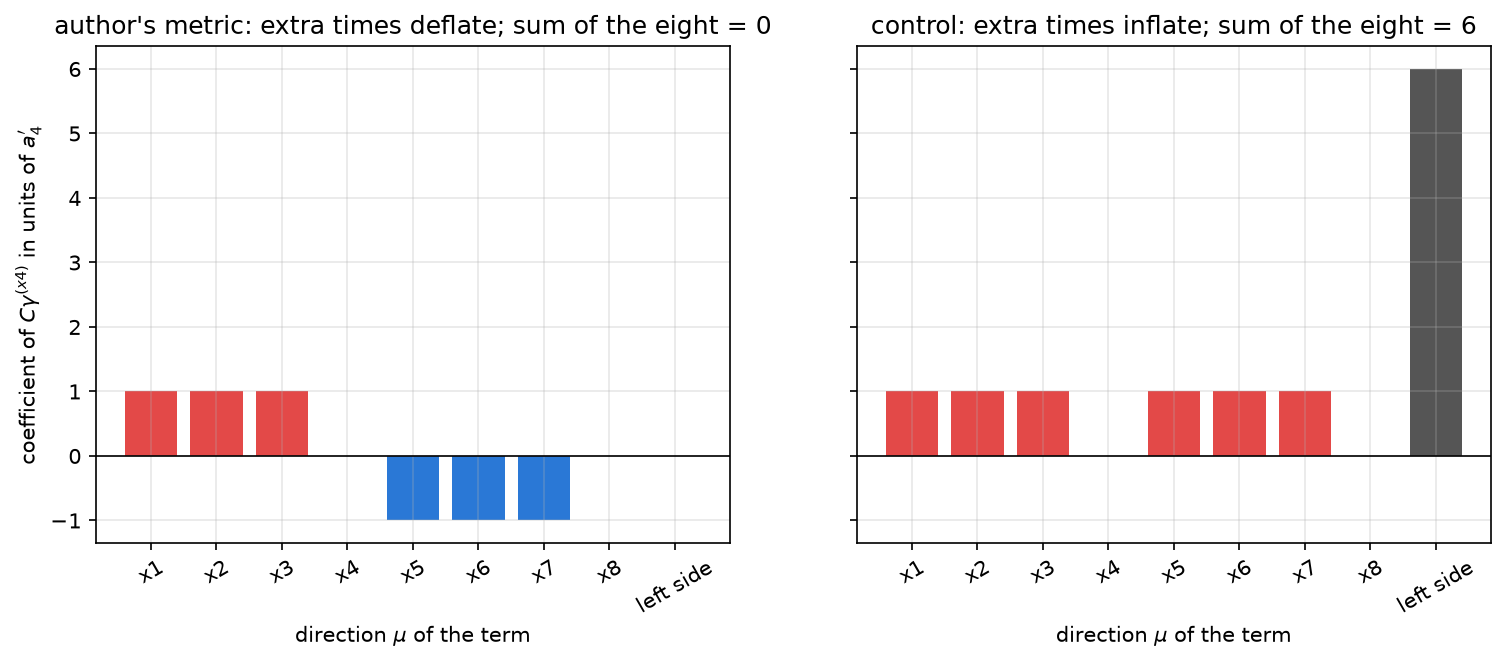

Figure 21b.1 saved as Revision/textbook/figures/21b_1_volume_balance.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3), sharey=True)
labels = COORDS + ["left side"]
for ax, data, lhs_value, title in (
        (axes[0], dfl, lhs_c4_dfl, "author's metric: extra times deflate"),
        (axes[1], ctl, lhs_c4, "control: extra times inflate")):
    heights = [float(sp.simplify(c[0] / a4p)) for c in data + [(lhs_value,)]]
    colours = ["#e34948" if h > 0 else ("#2a78d6" if h < 0 else "#999999")
               for h in heights[:8]] + ["#555555"]
    ax.bar(range(9), heights, color=colours)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xticks(range(9), labels, rotation=30)
    ax.set_title(title + f"; sum of the eight = {round(sum(heights[:8]))}")
    ax.set_xlabel("direction $\\mu$ of the term")
axes[0].set_ylabel("coefficient of $C\\gamma^{(x4)}$ in units of $a_4'$")
save_figure(fig, "volume_balance",
            "Why the time-derivative terms of the U(1) identity cancel. Each bar is "
            "the coefficient of $C\\gamma^{(x4)}$, in units of $a_4'$ and divided by "
            "the volume factor, contributed by one direction $\\mu$ to the right "
            "side $\\cos z\\,\\sum_\\mu(C\\gamma^\\mu\\Omega_\\mu - \\Omega_\\mu^T"
            "(\\gamma^\\mu)^TC)$; the last bar is the coefficient of the left "
            "side. Left: the author's metric, in which ordinary space contributes "
            "$+1$ per direction and the deflating extra times $-1$ each; the sum "
            "and the left side are $0$. Right: a control metric with inflating "
            "extra times; the six contributions add to $6$, matched by the growing "
            "volume factor $e^{6a_4}\\cos z$ on the left side.")

The next cell draws the three $16 \times 16$ matrices of the identity, divided by
$H\cos z$: the left side ($6C\gamma^{(x8)}$), the right side (the same matrix),
and the right side of the negative control without spin connection (zero).

LHS = RHS at the sample point to 1e-12: True


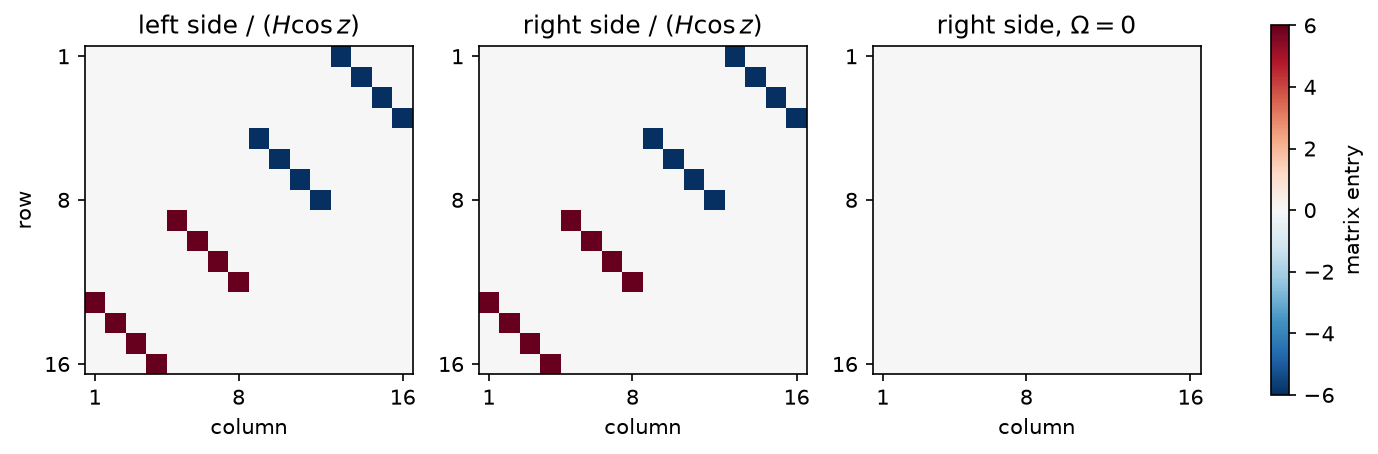

Figure 21b.2 saved as Revision/textbook/figures/21b_2_noether_matrices.png


In [8]:
from matplotlib.colors import TwoSlopeNorm

sample = {a4p: 0.7, a4: 0.3, H: sp.Rational(1, 6), x[7]: 0.5}  # any point


def sampled(matrix):
    """matrix / (H cos z) evaluated at the sample point, as numbers."""
    return np.array(sp.N((matrix / (H * sp.cos(z))).subs(a4p, 0.7).subs(sample))
                    .tolist(), dtype=float)


lhs_num, rhs_num = sampled(lhs), sampled(rhs)
say(f"LHS = RHS at the sample point to 1e-12: "
    f"{np.abs(lhs_num - rhs_num).max() < 1e-12}")
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.0))
norm = TwoSlopeNorm(vmin=-6, vcenter=0, vmax=6)  # blue negative, red positive
for ax, matrix, title in ((axes[0], lhs_num, "left side / $(H\\cos z)$"),
                          (axes[1], rhs_num, "right side / $(H\\cos z)$"),
                          (axes[2], 0 * rhs_num, "right side, $\\Omega = 0$")):
    image = ax.imshow(matrix, cmap="RdBu_r", norm=norm)
    ax.set_title(title)
    ax.set_xticks([0, 7, 15], ["1", "8", "16"])
    ax.set_yticks([0, 7, 15], ["1", "8", "16"])
    ax.set_xlabel("column")
    ax.grid(False)
axes[0].set_ylabel("row")
fig.colorbar(image, ax=axes, shrink=0.8, label="matrix entry")
save_figure(fig, "noether_matrices",
            "The $16 \\times 16$ matrices of the U(1) identity in the author's "
            "metric, divided by $H\\cos z$: left side $\\sum_\\mu\\partial_\\mu"
            "(\\cos z\\,C\\gamma^\\mu)$ (left panel), right side $\\cos z\\sum_\\mu"
            "(C\\gamma^\\mu\\Omega_\\mu - \\Omega_\\mu^T(\\gamma^\\mu)^TC)$ (middle) "
            "and the right side of the negative control with the spin connection "
            "removed (right); horizontal axis the column, vertical axis the row, "
            "colour the entry (red positive, blue negative). The first two are the "
            "same matrix $6C\\gamma^{(x8)}$ for every history $a_4$; without the "
            "spin connection the right side would be zero and the current would "
            "not be conserved.")

## 8. The Noether current from a local phase change

Noether's construction finds the current by making the phase depend on the
point: $\Psi \to e^{i\alpha(x)}\Psi$. Then $D_\mu(e^{i\alpha}\Psi) =
e^{i\alpha}(D_\mu\Psi + i(\partial_\mu\alpha)\Psi)$, and inserting this into the
kinetic term gives, line by line,
$$\tfrac12\big(\bar\Psi\gamma^\mu(D_\mu\Psi + i\alpha_\mu\Psi) - (D_\mu\bar\Psi -
i\alpha_\mu\bar\Psi)\gamma^\mu\Psi\big) = K + i\alpha_\mu\bar\Psi\gamma^\mu\Psi
= K - \alpha_\mu J^\mu ,$$
with $\alpha_\mu = \partial_\mu\alpha$ and $\bar\Psi\gamma^\mu\Psi = iJ^\mu$. So
$\mathcal{L}' - \mathcal{L} = -\cos z\,\alpha_\mu J^\mu$: the current is the
coefficient of $\partial_\mu\alpha$. The next cell checks this with numbers at one
point of the author's metric: it evaluates the full Lagrangian (with the spin
connection, $m = 0.7$, $\lambda = 0.3$, $U = \tfrac\lambda2S^2$) for a fixed
complex field value and fixed complex first derivatives, once as they are and once
after the local phase change, and compares the difference with $-\cos z\,
\alpha_\mu J^\mu$. With all $\alpha_\mu = 0$ (a constant phase) the Lagrangian
does not change at all.

In [9]:
point = {x[7]: 0.7, H: sp.Rational(1, 6)}  # z = 0.7 (H = 1/6, so z = x8)
A4_value, A4_slope = 0.4, 0.25  # a4 and a4' at the point (any values)


def at_point(expression):
    """A sympy expression evaluated at the point, as a numpy array of complex."""
    e = expression.subs(a4p, A4_slope).subs(a4, A4_value).subs(point)
    return np.array(sp.N(e).tolist(), dtype=complex) if hasattr(e, "tolist") \
        else complex(sp.N(e))


Om_num = [at_point(Om) for Om in Omega]  # Omega_mu at the point
f_num = [at_point(v).real for v in f_dfl]  # the scale factors at the point
g_up = [gamma[mu] / f_num[mu] for mu in range(8)]  # gamma^mu at the point
cos_num = np.cos(0.7)
m_val, lam = 0.7, 0.3
rng = np.random.default_rng(2102)  # fixed seed: the same numbers in every run
psi = rng.normal(size=16) + 1j * rng.normal(size=16)  # Psi at the point
dpsi = rng.normal(size=(8, 16)) + 1j * rng.normal(size=(8, 16))  # d_mu Psi
alpha_mu = rng.normal(size=8)  # the slopes d_mu alpha of the phase


def lagrangian(p, dp):
    """cos z [ (1/2)(Psibar gamma^mu D_mu Psi - (D_mu Psibar) gamma^mu Psi)
    - m S - (lambda/2) S^2 ] at the point, for the value p and derivatives dp."""
    bar = np.conj(p) @ C  # Psibar = Psi^dagger C
    kinetic = 0
    for mu in range(8):
        D = dp[mu] + Om_num[mu] @ p  # D_mu Psi
        Dbar = np.conj(dp[mu]) @ C - bar @ Om_num[mu]  # D_mu Psibar
        kinetic += (bar @ g_up[mu] @ D - Dbar @ g_up[mu] @ p) / 2
    S = bar @ p
    return cos_num * (kinetic - m_val * S - lam / 2 * S ** 2)


phase = np.exp(1j * 0.9)  # e^(i alpha) at the point, alpha = 0.9
L0 = lagrangian(psi, dpsi)
L_const = lagrangian(phase * psi, phase * dpsi)  # constant phase: alpha_mu = 0
L_local = lagrangian(phase * psi, phase * (dpsi + 1j * alpha_mu[:, None] * psi))
J = np.array([-1j * (np.conj(psi) @ C @ g_up[mu] @ psi) for mu in range(8)])
say(f"L = {L0.real:+.6f} (imaginary part below 1e-12: {abs(L0.imag) < 1e-12}); "
    f"after a constant phase {L_const.real:+.6f}")
say(f"L' - L = {(L_local - L0).real:+.6f};  -cos z alpha_mu J^mu = "
    f"{(-cos_num * alpha_mu @ J).real:+.6f}")
check(abs(L0.imag) < 1e-12 and abs(L_const - L0) < 1e-12
      and abs((L_local - L0) - (-cos_num * alpha_mu @ J)) < 1e-12
      and np.allclose(J.imag, 0),
      "L is real and phase invariant; a local phase changes it by -cos z "
      "(d_mu alpha) J^mu with J^mu = -i Psibar gamma^mu Psi real")

L = -16.780795 (imaginary part below 1e-12: True); after a constant phase -16.780795
L' - L = +2.348835;  -cos z alpha_mu J^mu = +2.348835
PASS L is real and phase invariant; a local phase changes it by -cos z (d_mu alpha) J^mu
    with J^mu = -i Psibar gamma^mu Psi real


## 9. The charge of an exact solution in the author's metric

The Revision field-theory record (formula exact_solutions, item (i)) gives the
exact solution with $U = 0$
$$\Psi = \sin^\alpha z\,\Big(\cos(wx_4)\,1 + \frac{\sin(wx_4)}{w}M\Big)\chi,\quad
M = -m\gamma^{(x4)} + b\,\gamma^{(x4)}\gamma^{(x8)},\quad b = 3H(2\alpha + 1),$$
written here for $k^2 = b^2 - m^2 = -w^2 < 0$ (then $\cosh(kx_4) = \cos(wx_4)$
and $\sinh(kx_4)/k = \sin(wx_4)/w$). It does not depend on $x1, x2, x3, x5, x6,
x7$, so the factors $e^{\pm a_4}$ of the field equation multiply derivatives that
vanish: it solves the field equation for **every** history $a_4$, the deflating
one included. We take $H = 1/6$ (so $z = x_8$), $\alpha = 1$, $m = 2$, so $b =
3/2$ and $w = \sqrt7/2$, and a fixed complex column $\chi$ with exact rational
entries. The current has two nonzero components:
$$\cos z\,J^{(x4)} = \cos z\,\Psi^\dagger B\Psi,\qquad
\cos z\,J^{(x8)} = \cos z\tan z\,\Psi^\dagger K_8\Psi = \sin z\,\Psi^\dagger K_8
\Psi,\quad K_8 = -iC\gamma^{(x8)},$$
because $\gamma^{x8} = \gamma^{(x8)}/f_8 = \tan z\,\gamma^{(x8)}$. The next cell
checks that the record states item (i) word for word as used here (in Wolfram
notation, `al` is $\alpha$ and $k^2 = 9H^2(2\alpha + 1)^2 - m^2 = b^2 - m^2$),
builds $\Psi$, checks the field equation exactly, and checks the local
conservation law $\partial_4(\cos z\,J^{(x4)}) + \partial_z(\cos z\,J^{(x8)}) = 0$
exactly ($\partial_8 = \partial_z$ for $H = 1/6$).

In [10]:
x4, zz = sp.symbols("x4 z", real=True)  # the time and the angle z = x8
Hn, al, m_sol = sp.Rational(1, 6), 1, 2
b_sol = 3 * Hn * (2 * al + 1)  # 3/2
w = sp.sqrt(m_sol ** 2 - b_sol ** 2)  # sqrt(7)/2
M_sol = -m_sol * G[3] + b_sol * G[3] * G[7]
U_sol = sp.cos(w * x4) * sp.eye(16) + sp.sin(w * x4) / w * M_sol  # a real matrix
chi_values = [(0.62, -0.31), (0.15, 0.88), (-0.47, 0.26), (0.93, -0.05),
              (-0.21, -0.64), (0.38, 0.12), (0.07, -0.93), (-0.85, 0.44),
              (0.51, 0.69), (-0.12, -0.27), (0.29, 0.58), (-0.66, 0.03),
              (0.44, -0.72), (0.81, 0.35), (-0.39, -0.18), (0.24, 0.97)]
chi = sp.Matrix([sp.Rational(round(100 * re), 100) + sp.I * sp.Rational(
    round(100 * im), 100) for re, im in chi_values])  # exact rational entries
Psi = sp.sin(zz) ** al * U_sol * chi
tan_z = sp.sin(zz) / sp.cos(zz)
E = (G[3] * Psi.diff(x4) + 6 * Hn * tan_z * G[7] * Psi.diff(zz)
     + 3 * Hn * G[7] * Psi - m_sol * Psi)  # the field equation, U = 0
SOLUTION_I = (  # item (i) of the record's formula exact_solutions, word for word
    "(i) U = 0: Psi = Sin[z]^al (Cosh[k x4] + Sinh[k x4]/k M) chi, M = -m g[x4]"
    " + 3 H (2 al + 1) g[x4].g[x8], k^2 = 9 H^2 (2 al + 1)^2 - m^2 (any a4)")
check(E.expand() == sp.zeros(16, 1)
      and THEORY["exact_solutions"]["wl"].startswith(SOLUTION_I + "; ")
      and PY_THEORY["exact_solution_family_x4_x8"] == "PASS",
      "the record's exact solution solves the field equation (m = 2)",
      record="Revision/theory/reports/python-field-theory.json, check "
      "exact_solution_family_x4_x8")
B_s = -sp.I * C_s * G[3]
K8_s = -sp.I * C_s * G[7]
density = sp.cos(zz) * (Psi.H * B_s * Psi)[0, 0]  # cos z J^(x4)
flux = sp.sin(zz) * (Psi.H * K8_s * Psi)[0, 0]  # cos z J^(x8)
divergence = sp.expand(sp.diff(density, x4) + sp.diff(flux, zz))
check(sp.simplify(divergence) == 0
      and PY_THEORY["commuting_current_conservation"] == "PASS",
      "d4(cos z J^(x4)) + dz(cos z J^(x8)) = 0 exactly for the exact solution",
      record="Revision/theory/reports/python-field-theory.json, check "
      "commuting_current_conservation")

PASS the record's exact solution solves the field equation (m = 2)
     reproduces Revision/theory/reports/python-field-theory.json, check
    exact_solution_family_x4_x8
PASS d4(cos z J^(x4)) + dz(cos z J^(x8)) = 0 exactly for the exact solution
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_current_conservation


The next cell draws the charge density $\cos z\,J^{(x4)}$ over the time $x_4$ and
the angle $z$, for $\Psi$ and for its chirality partner $\Gamma\Psi$, and their
sum. The partner is a solution of the field equation with the mass reversed
(theorem T1 of the Revision pairing record, here with $\lambda = 0$); the cell
checks this exactly and checks that its whole current is the opposite of that of
$\Psi$, so the sum is zero everywhere (record checks T1_current_primordial_commuting
and T1.metric.commuting.current).

PASS Gamma Psi solves the equation with mass -2 and carries the opposite current: the
    pair's total current is zero
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    T1_current_primordial_commuting


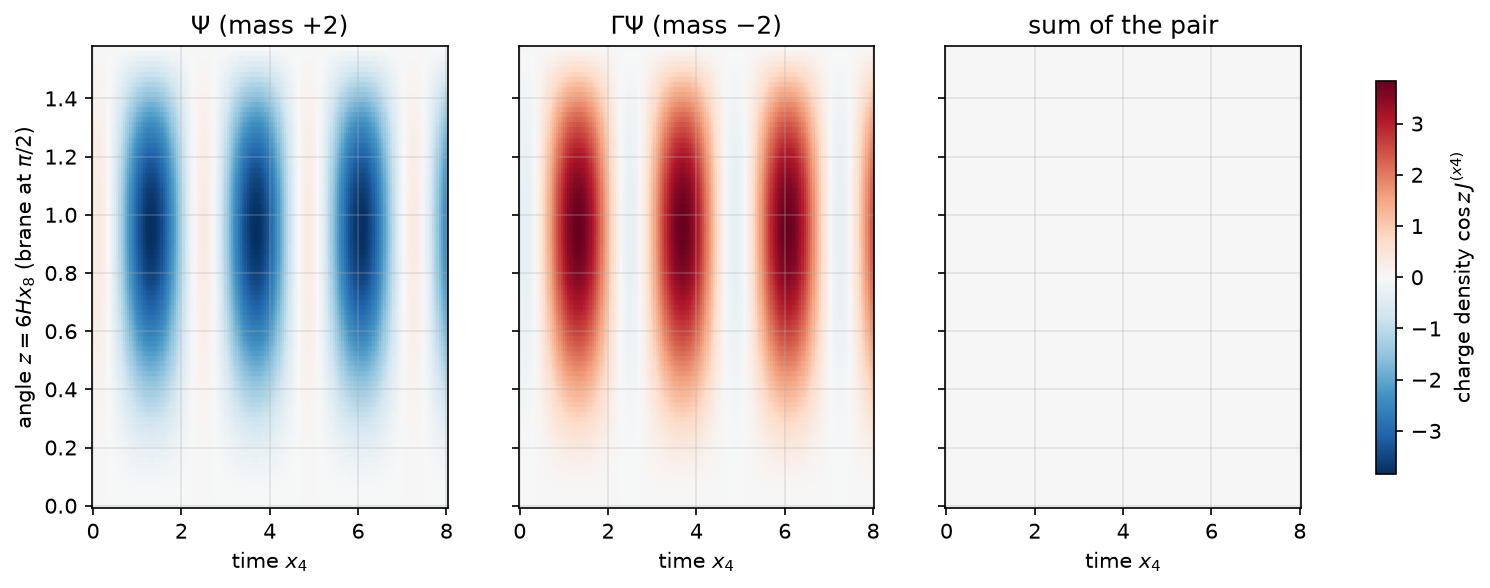

Figure 21b.3 saved as Revision/textbook/figures/21b_3_charge_density_maps.png


In [11]:
Gamma_s = sp.Matrix(Gamma.tolist())
partner = Gamma_s * Psi
E_partner = (G[3] * partner.diff(x4) + 6 * Hn * tan_z * G[7] * partner.diff(zz)
             + 3 * Hn * G[7] * partner + m_sol * partner)  # mass -2
density_p = sp.cos(zz) * (partner.H * B_s * partner)[0, 0]
flux_p = sp.sin(zz) * (partner.H * K8_s * partner)[0, 0]
check(E_partner.expand() == sp.zeros(16, 1)
      and sp.expand(density_p + density) == 0 and sp.expand(flux_p + flux) == 0
      and WL_PAIR["T1_current_primordial_commuting"] == "PASS"
      and PY_PAIR["T1.metric.commuting.current"] == "PASS",
      "Gamma Psi solves the equation with mass -2 and carries the opposite "
      "current: the pair's total current is zero",
      record="Revision/pairing/reports/wolfram-pairing.json, check "
      "T1_current_primordial_commuting")

density_f = sp.lambdify((x4, zz), density, "numpy")
times = np.linspace(0.0, 8.0, 161)
angles = np.linspace(0.0, np.pi / 2, 91)
T, Z = np.meshgrid(times, angles)  # every pair (time, angle)
rho = np.real(density_f(T, Z))  # the charge density of Psi
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0), sharey=True)
limit = np.abs(rho).max()
for ax, values, title in ((axes[0], rho, "$\\Psi$ (mass $+2$)"),
                          (axes[1], -rho, "$\\Gamma\\Psi$ (mass $-2$)"),
                          (axes[2], rho - rho, "sum of the pair")):
    image = ax.pcolormesh(T, Z, values, cmap="RdBu_r", vmin=-limit, vmax=limit,
                          shading="auto")
    ax.set_title(title)
    ax.set_xlabel("time $x_4$")
axes[0].set_ylabel("angle $z = 6Hx_8$ (brane at $\\pi/2$)")
fig.colorbar(image, ax=axes, shrink=0.85, label="charge density $\\cos z\\,J^{(x4)}$")
save_figure(fig, "charge_density_maps",
            "The charge density $\\cos z\\,J^{(x4)}$ of an exact solution of the "
            "field equation in the author's metric ($H = 1/6$, $\\alpha = 1$, mass "
            "$+2$; left), of its chirality partner $\\Gamma\\Psi$ (a solution with "
            "mass $-2$; middle) and of the pair (right); horizontal axis the time "
            "$x_4$, vertical axis the angle $z = 6Hx_8$ from the tip $0$ to the "
            "brane $\\pi/2$, colour the density (red positive, blue negative, pure "
            "numbers). The partner carries exactly the opposite density at every "
            "point, so the pair carries none.")

## 10. The charge balance and a solution with zero flux

Integrate the conservation law over the patch $0 < z < \pi/2$ (for each unit of
the other six coordinates). Since $\Psi$ contains $\sin z$, the density is
$\cos z\,\sin^2z\,f(x_4)$ with $f = \chi^\dagger U^TBU\chi$, and the charge is
$$Q(x_4) = \int_0^{\pi/2}\cos z\,\sin^2 z\,dz\;f(x_4) = \tfrac13 f(x_4)$$
(substitute $u = \sin z$: $\int_0^1 u^2\,du = 1/3$). The flux $\sin^3z\,g(x_4)$,
$g = \chi^\dagger U^TK_8U\chi$, vanishes at the tip $z = 0$ and equals $g(x_4)$ at
the brane $z = \pi/2$. The fundamental theorem of calculus gives the **charge
balance**
$$Q(x_4) - Q(0) = -\int_0^{x_4} g(t)\,dt :$$
the charge of the patch changes exactly by what flows out through the brane. The
next cell checks this exactly (sympy integrates $g$ exactly).

Can the flux vanish? Since $M^2 = -w^2\,1$, the matrix $P = \tfrac12(1 - iM/w)$
satisfies $P^2 = P$ (a projector) and $MP = iwP$. For $\chi_0 = P\chi$ we get
$M\chi_0 = iw\chi_0$, hence $U\chi_0 = (\cos(wx_4) + i\sin(wx_4))\chi_0 =
e^{iwx_4}\chi_0$, and the solution $\Psi_0 = \sin z\,e^{iwx_4}\chi_0$ has a
single frequency: it is a **stationary state**. Its charge density
$\cos z\sin^2z\,\chi_0^\dagger B\chi_0$ does not depend on the time, so by the
conservation law its flux is zero, and its charge $Q$ is **constant**. The cell
checks this too, and that this constant is not zero.

In [12]:
t = sp.symbols("t", real=True)
f_of = sp.expand((U_sol * chi).H * B_s * (U_sol * chi))[0, 0]  # f(x4)
g_of = sp.expand((U_sol * chi).H * K8_s * (U_sol * chi))[0, 0]  # g(x4)
Q_of = f_of / 3
balance = sp.simplify(Q_of - Q_of.subs(x4, 0)
                      + sp.integrate(g_of.subs(x4, t), (t, 0, x4)))
check(balance == 0, "charge balance: Q(x4) - Q(0) = - (flux through the brane), "
      "exactly")

P_stat = (sp.eye(16) - sp.I * M_sol / w) / 2  # projector onto M chi = i w chi
chi0 = P_stat * chi  # the single-frequency part of chi
g0 = sp.simplify(sp.expand((U_sol * chi0).H * K8_s * (U_sol * chi0))[0, 0])
Q0 = sp.simplify(sp.expand((U_sol * chi0).H * B_s * (U_sol * chi0))[0, 0] / 3)
check((P_stat * P_stat - P_stat).applyfunc(sp.simplify) == sp.zeros(16, 16)
      and (M_sol * chi0 - sp.I * w * chi0).applyfunc(sp.simplify) == sp.zeros(16, 1)
      and g0 == 0 and Q0.free_symbols == set() and Q0 != 0,
      "the stationary solution sin z exp(i w x4) chi0: zero flux, constant nonzero Q")
report("charge of the general solution at x4 = 0",
       f"{float(sp.re(Q_of.subs(x4, 0))):.6f}")
report("constant charge of the stationary solution", f"{Q0} = {float(Q0):.6f}")

PASS charge balance: Q(x4) - Q(0) = - (flux through the brane), exactly
PASS the stationary solution sin z exp(i w x4) chi0: zero flux, constant nonzero Q
RESULT charge of the general solution at x4 = 0 = 0.178467
RESULT constant charge of the stationary solution = -1424/1875 - 13*sqrt(7)/1500 =
    -0.782397


The next cell draws the balance: on the left, for the general $\chi$, the charge
$Q(x_4)$ and the right side $Q(0) - \int_0^{x_4}g$ (they lie on top of each
other) together with the flux $g$ through the brane; on the right, for $\chi_0$,
the constant charge of $\Psi$, of its partner and of the pair.

PASS numerically: Q(x4) and Q(0) minus the integrated flux agree to 1e-12


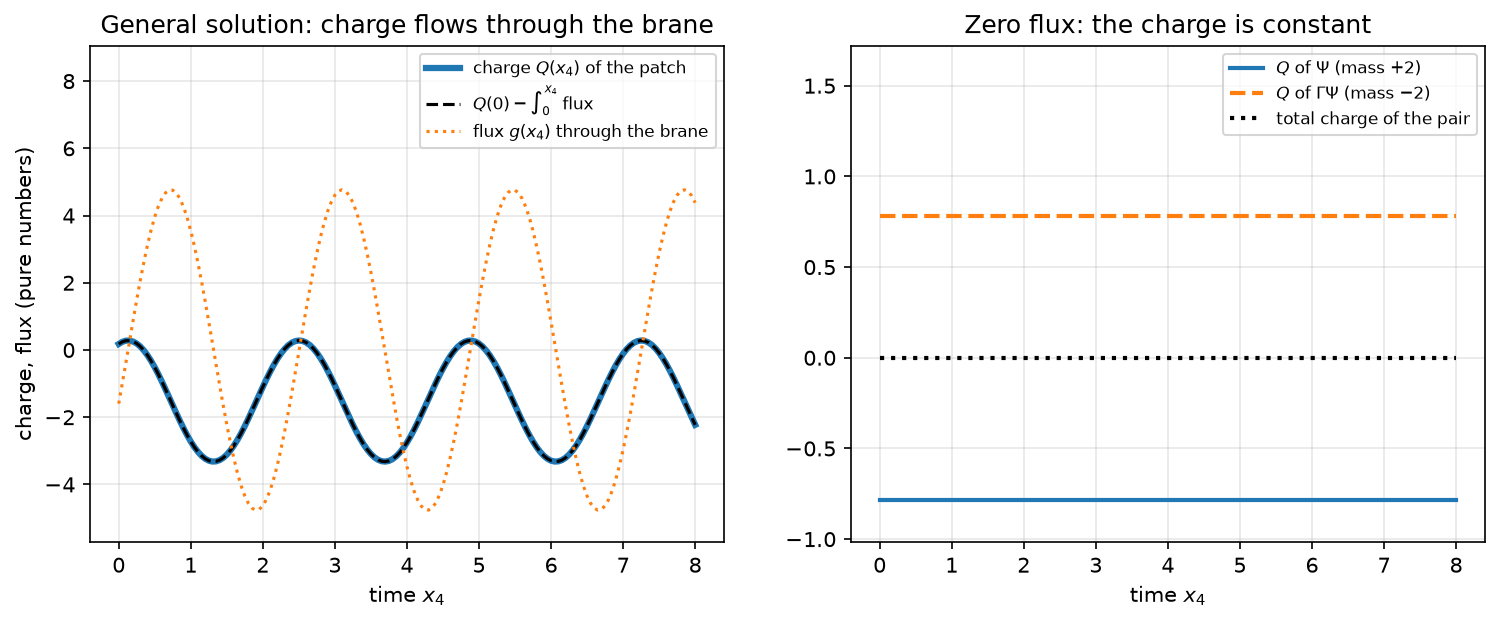

Figure 21b.4 saved as Revision/textbook/figures/21b_4_charge_balance.png


In [13]:
Q_f = sp.lambdify(x4, Q_of, "numpy")
g_f = sp.lambdify(x4, g_of, "numpy")
integral_f = sp.lambdify(x4, sp.integrate(g_of.subs(x4, t), (t, 0, x4)), "numpy")
Q_vals = np.real(Q_f(times))
rhs_vals = np.real(Q_f(0.0) - integral_f(times))
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))
axes[0].plot(times, Q_vals, linewidth=3, label="charge $Q(x_4)$ of the patch")
axes[0].plot(times, rhs_vals, "--", color="black",
             label="$Q(0) - \\int_0^{x_4}$ flux")
axes[0].plot(times, np.real(g_f(times)), ":", label="flux $g(x_4)$ through the brane")
axes[0].set_xlabel("time $x_4$")
axes[0].set_ylabel("charge, flux (pure numbers)")
axes[0].set_title("General solution: charge flows through the brane")
top = 1.9 * np.abs(np.real(g_f(times))).max()  # room for the legend above
axes[0].set_ylim(-1.2 * np.abs(np.real(g_f(times))).max(), top)
axes[0].legend(fontsize=8, loc="upper right")
Q0_value = float(Q0)
axes[1].plot(times, np.full_like(times, Q0_value), linewidth=2,
             label="$Q$ of $\\Psi$ (mass $+2$)")
axes[1].plot(times, np.full_like(times, -Q0_value), "--", linewidth=2,
             label="$Q$ of $\\Gamma\\Psi$ (mass $-2$)")
axes[1].plot(times, np.zeros_like(times), ":", color="black", linewidth=2,
             label="total charge of the pair")
axes[1].set_xlabel("time $x_4$")
axes[1].set_title("Zero flux: the charge is constant")
axes[1].set_ylim(-1.3 * abs(Q0_value), 2.2 * abs(Q0_value))  # legend fits on top
axes[1].legend(fontsize=8, loc="upper right")
check(np.max(np.abs(Q_vals - rhs_vals)) < 1e-12,
      "numerically: Q(x4) and Q(0) minus the integrated flux agree to 1e-12")
save_figure(fig, "charge_balance",
            "The charge balance of exact solutions in the author's metric ($H = "
            "1/6$, $\\alpha = 1$, mass $2$). Left: for a general column $\\chi$, "
            "the charge $Q(x_4)$ of the patch $0 < z < \\pi/2$ (thick line), the "
            "prediction $Q(0) - \\int_0^{x_4} g$ of the conservation law (dashed, "
            "on top of it) and the flux $g$ through the brane (dotted), versus the "
            "time $x_4$. Right: for the stationary solution $\\sin z\\,e^{iwx_4}"
            "\\chi_0$ the flux vanishes, its charge is constant, its chirality "
            "partner "
            "carries the opposite constant charge and the pair carries none. All "
            "quantities per unit of the other six coordinates (pure numbers).")

**A finite-difference test.** A computer usually checks a conservation law with
numbers on a grid, replacing each derivative by a *central difference*
$\partial_x F \approx (F(x + h) - F(x - h))/(2h)$, whose error is proportional to
$h^2$. The next cell evaluates the divergence $\partial_4(\cos z\,J^{(x4)}) +
\partial_z(\cos z\,J^{(x8)})$ this way at the point $(x_4, z) = (1.3, 0.7)$ for
steps $h = 0.2, 0.1, \dots$: the result is not zero, but it shrinks by a factor 4
each time $h$ is halved (second-order convergence) towards the exact value 0.

residuals: 3.68e-03, 9.29e-04, 2.33e-04, 5.82e-05, 1.46e-05, 3.64e-06, 9.10e-07
ratios when h is halved: 3.966, 3.991, 3.998, 3.999, 4.000, 4.000
PASS finite differences: the residual falls by 4 when h is halved (order 2)


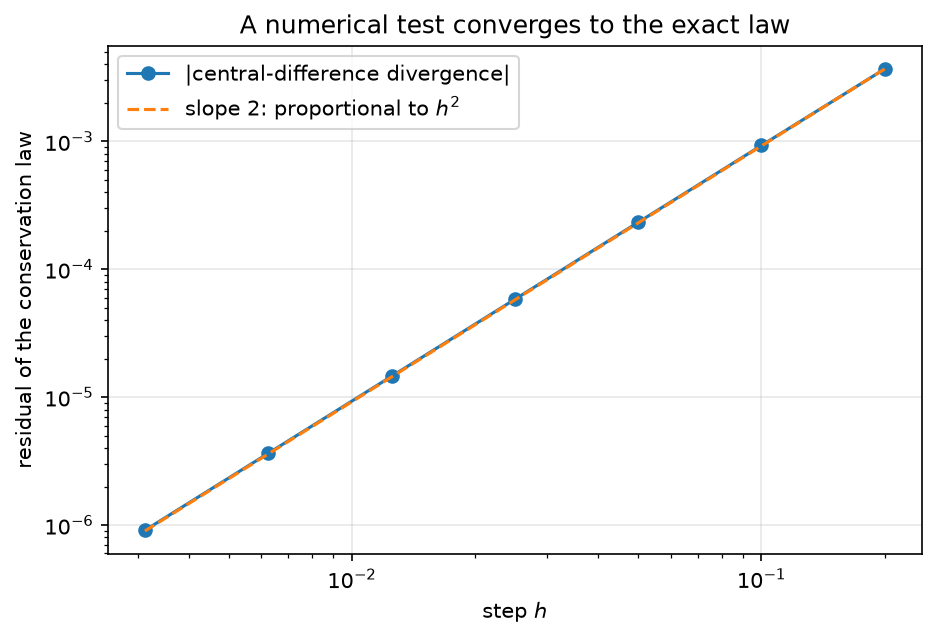

Figure 21b.5 saved as Revision/textbook/figures/21b_5_local_conservation.png


In [14]:
flux_f = sp.lambdify((x4, zz), flux, "numpy")
steps = 0.2 / 2.0 ** np.arange(7)  # 0.2, 0.1, ..., 0.003125
t0, z0 = 1.3, 0.7
residuals = np.array([abs(np.real(
    (density_f(t0 + h, z0) - density_f(t0 - h, z0)) / (2 * h)
    + (flux_f(t0, z0 + h) - flux_f(t0, z0 - h)) / (2 * h))) for h in steps])
ratios = residuals[:-1] / residuals[1:]
say("residuals: " + ", ".join(f"{r:.2e}" for r in residuals))
say("ratios when h is halved: " + ", ".join(f"{q:.3f}" for q in ratios))
check(np.all(np.abs(ratios - 4.0) < 0.05),
      "finite differences: the residual falls by 4 when h is halved (order 2)")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.loglog(steps, residuals, "o-", label="|central-difference divergence|")
ax.loglog(steps, residuals[0] * (steps / steps[0]) ** 2, "--",
          label="slope 2: proportional to $h^2$")
ax.set_xlabel("step $h$")
ax.set_ylabel("residual of the conservation law")
ax.set_title("A numerical test converges to the exact law")
ax.legend()
save_figure(fig, "local_conservation",
            "The local conservation law $\\partial_4(\\cos z\\,J^{(x4)}) + "
            "\\partial_z(\\cos z\\,J^{(x8)}) = 0$ tested with central differences "
            "of step $h$ at the point $x_4 = 1.3$, $z = 0.7$ for the exact solution "
            "of the author's metric; horizontal axis the step $h$, vertical axis "
            "the size of the computed divergence, both on logarithmic scales "
            "(pure numbers). The points follow the dashed line of slope 2: the "
            "error of the difference formula, proportional to $h^2$, is all there "
            "is; the exact divergence is zero.")

**The charge while the extra times deflate.** The next cell draws, on a common
time axis, the scale factors of the author's metric for the linear history
$a_4 = AHx_4$ (here $A = 1$, $H = 1/6$, chosen only for the picture): ordinary
space grows as $e^{a_4}$, the extra times shrink as $e^{-a_4}$, the volume factor
$e^{3a_4}e^{-3a_4} = 1$ stays; and below, the charge of the stationary (zero-flux)
solution, which stays constant. The conservation law was verified for a general
$a_4(x_4)$, so any other history gives the same constant charge.

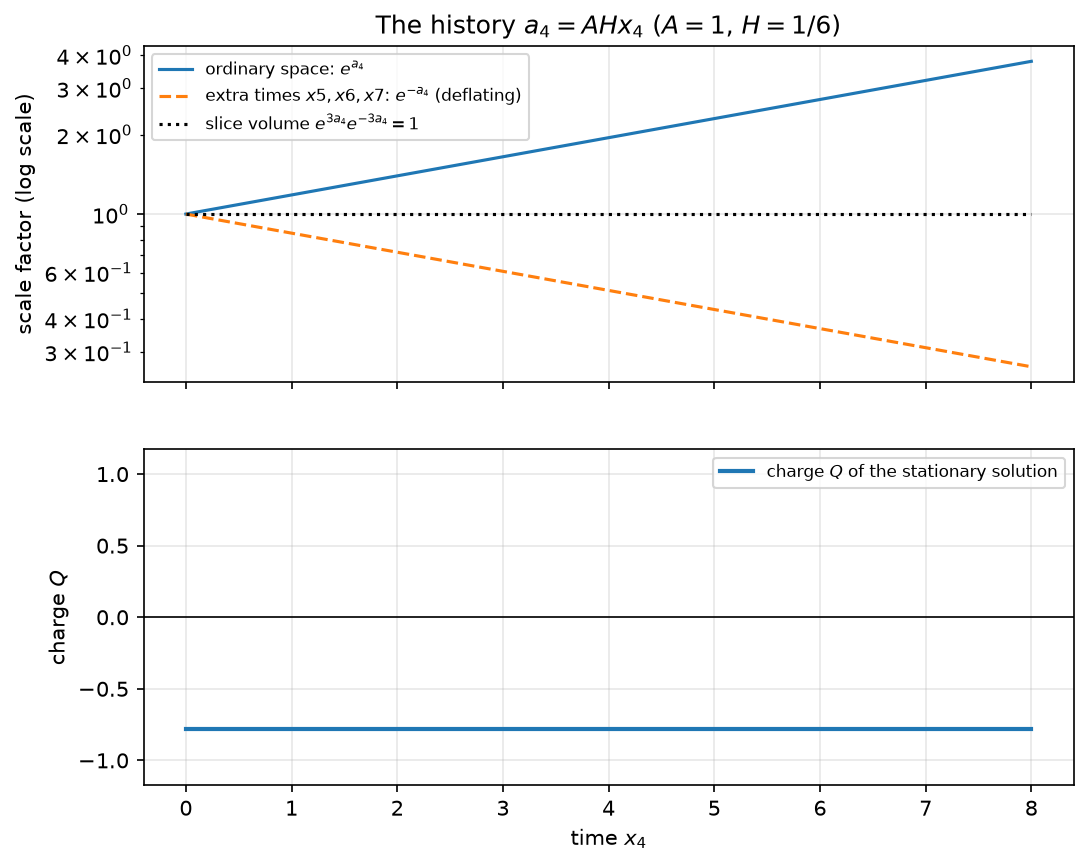

Figure 21b.6 saved as Revision/textbook/figures/21b_6_charge_through_deflation.png


In [15]:
a4_vals = times / 6.0  # a4 = A H x4 with A = 1, H = 1/6
fig, axes = plt.subplots(2, 1, figsize=(8.0, 6.4), sharex=True)
axes[0].semilogy(times, np.exp(a4_vals), label="ordinary space: $e^{a_4}$")
axes[0].semilogy(times, np.exp(-a4_vals), "--",
                 label="extra times $x5, x6, x7$: $e^{-a_4}$ (deflating)")
axes[0].semilogy(times, np.exp(3 * a4_vals) * np.exp(-3 * a4_vals), ":",
                 color="black", label="slice volume $e^{3a_4}e^{-3a_4} = 1$")
axes[0].set_ylabel("scale factor (log scale)")
axes[0].set_title("The history $a_4 = AHx_4$ ($A = 1$, $H = 1/6$)")
axes[0].legend(fontsize=8)
axes[1].plot(times, np.full_like(times, Q0_value), linewidth=2,
             label="charge $Q$ of the stationary solution")
axes[1].set_ylim(-1.5 * abs(Q0_value), 1.5 * abs(Q0_value))
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("time $x_4$")
axes[1].set_ylabel("charge $Q$")
axes[1].legend(fontsize=8)
save_figure(fig, "charge_through_deflation",
            "Top: the scale factors of the author's metric along the time $x_4$ "
            "for the linear history $a_4 = AHx_4$ with $A = 1$, $H = 1/6$ "
            "(chosen for the picture): ordinary space $e^{a_4}$ grows, the three "
            "extra times $e^{-a_4}$ deflate exponentially, and their product, the "
            "volume factor of a slice, stays $1$ (logarithmic vertical scale). "
            "Bottom: the charge $Q$ of the stationary exact solution versus $x_4$; "
            "it does not change while space inflates and the extra times deflate. "
            "The U(1) identity was verified for every history $a_4$, so the "
            "constancy does not depend on this choice.")

## 11. The charge density can be negative

The charge density $J^{(x4)} = \Psi^\dagger B\Psi$ is a *quadratic form* with the
matrix $B$, which has eight eigenvalues $+1$ and eight eigenvalues $-1$
(signature (8,8)). Writing $\Psi$ in the eigenvectors of $B$ as $\Psi = \sum_j c_j
v_j$ gives $\Psi^\dagger B\Psi = \sum_{B = +1}|c_j|^2 - \sum_{B = -1}|c_j|^2$, which
can have either sign; divided by $\Psi^\dagger\Psi = \sum|c_j|^2$ it lies between
$-1$ and $+1$.

**A worked example in flat space** ($H = 0$, $a_4$ constant). The field equation
along the time is $\gamma^{(x4)}\partial_4\Psi = m\Psi$. A *rest state* $\Psi =
u\,e^{-imx_4}$ with $-i\gamma^{(x4)}u = u$ solves it: $\gamma^{(x4)}(-im)u =
m(-i\gamma^{(x4)})u = mu$; it has the positive frequency $m$. Since $B =
C(-i\gamma^{(x4)})$ and $C$ commutes with $\gamma^{(x4)}$, $B$ maps the
8-dimensional space of such $u$ into itself and has there four eigenvalues $+1$
(vector $u_+$) and four $-1$ (vector $u_-$). For $u = \tfrac35u_+ + \tfrac45u_-$
(normalised) the charge density is $\tfrac{9}{25} - \tfrac{16}{25} =
-\tfrac{7}{25}$: a positive-frequency field with negative charge density. The
next cell computes this exactly from the gammas and draws the distribution of
$\Psi^\dagger B\Psi/\Psi^\dagger\Psi$ for 20000 random columns.

PASS B has signature (8,8); a positive-frequency rest state has charge density -7/25
RESULT charge density of the rest state 3/5 u+ + 4/5 u- = -7/25
fraction of random columns with negative charge density: 0.504
PASS random columns: the ratio lies in [-1, 1] and takes both signs


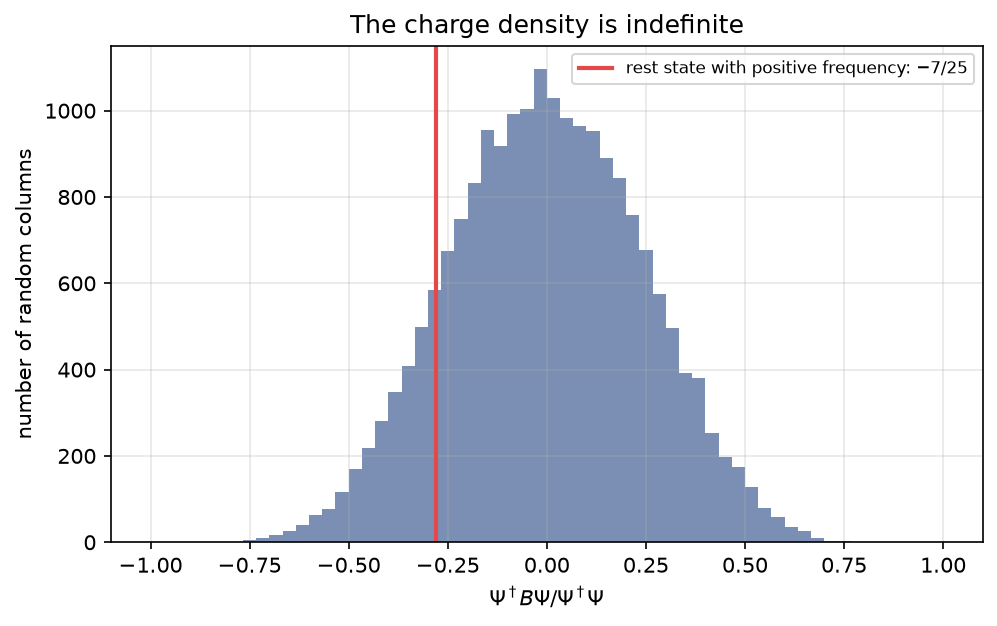

Figure 21b.7 saved as Revision/textbook/figures/21b_7_indefinite_charge.png


In [16]:
from fractions import Fraction

eig_B = np.linalg.eigvalsh(B)
plus_space = (I16 - 1j * gamma[3]) / 2  # projector onto -i gamma^(x4) = +1
# B restricted to that space: an 8-dimensional block, eigenvalues +-1
values, vectors = np.linalg.eigh(plus_space @ B @ plus_space)
u_plus = vectors[:, np.argmax(values)]  # a vector with -i g4 u = u, B u = +u
u_minus = vectors[:, np.argmin(values)]  # a vector with -i g4 u = u, B u = -u
u = 0.6 * u_plus + 0.8 * u_minus  # 3/5 and 4/5
rest_density = np.conj(u) @ B @ u
restricted = np.linalg.eigvalsh(plus_space @ B @ plus_space)
check(np.allclose(sorted(eig_B), [-1] * 8 + [1] * 8)
      and np.allclose(-1j * gamma[3] @ u, u)
      and np.sum(restricted > 0.5) == 4 and np.sum(restricted < -0.5) == 4
      and abs(rest_density - (-7 / 25)) < 1e-12,
      "B has signature (8,8); a positive-frequency rest state has charge density "
      "-7/25")
report("charge density of the rest state 3/5 u+ + 4/5 u-",
       Fraction(round(rest_density.real * 25), 25))

samples = rng.normal(size=(20000, 16)) + 1j * rng.normal(size=(20000, 16))
ratio = (np.einsum("nr,rc,nc->n", np.conj(samples), B, samples).real
         / np.einsum("nr,nr->n", np.conj(samples), samples).real)
say(f"fraction of random columns with negative charge density: "
    f"{np.mean(ratio < 0):.3f}")
check(ratio.min() >= -1 - 1e-12 and ratio.max() <= 1 + 1e-12
      and 0.4 < np.mean(ratio < 0) < 0.6,
      "random columns: the ratio lies in [-1, 1] and takes both signs")
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.hist(ratio, bins=60, range=(-1, 1), color="#7a8fb3")
ax.axvline(-7 / 25, color="#e34948", linewidth=2,
           label="rest state with positive frequency: $-7/25$")
ax.set_xlabel("$\\Psi^\\dagger B\\Psi / \\Psi^\\dagger\\Psi$")
ax.set_ylabel("number of random columns")
ax.set_title("The charge density is indefinite")
ax.legend(fontsize=8)
save_figure(fig, "indefinite_charge",
            "Histogram of the normalised charge density $\\Psi^\\dagger B\\Psi / "
            "\\Psi^\\dagger\\Psi$ for 20000 random complex columns $\\Psi$ (fixed "
            "seed); horizontal axis the ratio, from $-1$ to $+1$, vertical axis the "
            "number of columns in each of 60 bins. Because $B$ has eight "
            "eigenvalues $+1$ and eight $-1$, the ratio takes both signs equally "
            "often. The red line marks the worked example: a flat-space rest "
            "state of positive frequency with charge density $-7/25$.")

## 12. The pair-level charge bookkeeping

Theorem T1 of the Revision pairing record says: for every configuration $\Psi$ of
the theory with $(m, \lambda)$, the chirality partner $\Gamma\Psi$ is a
configuration of the theory with $(-m, -\lambda)$, and $J^\mu[\Gamma\Psi] =
-J^\mu[\Psi]$ at every point. Hence a pair $\{\Psi, \Gamma\Psi\}$ has total
charge $Q + Q' = 0$ **as classical bilinears**. The next cell checks the
pointwise statement with numbers for five random columns at three times, using
the exact solution's matrix $U(x_4)$: it computes $Q$ of $\Psi$, of $\Gamma\Psi$
and their sum, and draws them. (What this does *not* say: it does not make two
independently quantised universes cancel each other, and it does not create
anything; a single universe with charge $Q$ is an equally valid solution.)

PASS five random columns at three times: Q + Q(partner) = 0, Q itself nonzero


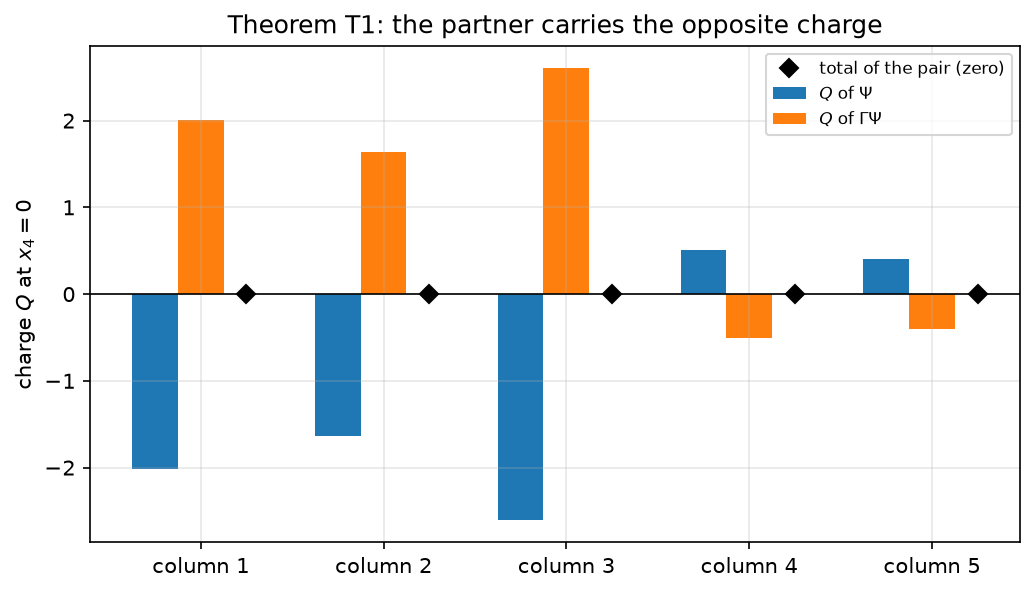

Figure 21b.8 saved as Revision/textbook/figures/21b_8_pair_bookkeeping.png


In [17]:
U_f = sp.lambdify(x4, U_sol, "numpy")
columns = rng.normal(size=(5, 16)) + 1j * rng.normal(size=(5, 16))
check_times = [0.0, 2.5, 5.0]
totals, charges = [], []
for col in columns:
    u_t = [np.array(U_f(tt), dtype=float) @ col for tt in check_times]
    q_psi = [np.conj(v) @ B @ v / 3 for v in u_t]  # Q = f / 3 for alpha = 1
    q_par = [np.conj(Gamma @ v) @ B @ (Gamma @ v) / 3 for v in u_t]
    charges.append((q_psi[0].real, q_par[0].real))
    totals += [abs(a + b_) for a, b_ in zip(q_psi, q_par)]
check(max(totals) < 1e-12 and min(abs(c[0]) for c in charges) > 1e-3,
      "five random columns at three times: Q + Q(partner) = 0, Q itself nonzero")

fig, ax = plt.subplots(figsize=(8.0, 4.3))
idx = np.arange(5)
ax.bar(idx - 0.25, [c[0] for c in charges], width=0.25, label="$Q$ of $\\Psi$")
ax.bar(idx, [c[1] for c in charges], width=0.25, label="$Q$ of $\\Gamma\\Psi$")
ax.plot(idx + 0.25, [c[0] + c[1] for c in charges], "D", color="black",
        label="total of the pair (zero)")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(idx, [f"column {k + 1}" for k in idx])
ax.set_ylabel("charge $Q$ at $x_4 = 0$")
ax.set_title("Theorem T1: the partner carries the opposite charge")
ax.legend(fontsize=8)
save_figure(fig, "pair_bookkeeping",
            "Pair-level charge bookkeeping for five random columns $\\chi$ in the "
            "exact solution of the author's metric: the charge $Q$ of $\\Psi$ "
            "(left bar of each group), of its chirality partner $\\Gamma\\Psi$, a "
            "solution with the mass reversed (right bar), and their total (black "
            "diamond, zero); horizontal axis the column, vertical axis the charge at "
            "$x_4 = 0$ per unit of the other six coordinates (pure numbers). The "
            "charges of single universes can have either sign and any size; only "
            "the pair adds to zero.")

## 13. The figure files

The last cell checks that the eight figure files exist and prints the number of
checks that passed.

In [18]:
names = sorted(FIGURE_NUMBERS, key=FIGURE_NUMBERS.get)
check(len(names) == 8 and all(
    output_file(f"{FIGURE_FOLDER}/21b_{FIGURE_NUMBERS[n]}_{n}.png").is_file()
    for n in names), "the eight figure files of notebook 21b exist")
all_checks_passed()

PASS the eight figure files of notebook 21b exist
ALL 21 CHECKS PASSED (notebook 21b)


## 14. What this notebook showed

- PROVED (exact, sympy, for a general history $a_4(x_4)$): the canonical spin
  connection of the author's metric is real and gives $\gamma^\mu\Omega_\mu =
  3H\gamma^{(x8)}$; the U(1) Noether identity reduces to the matrix identity
  $\sum_\mu\partial_\mu(\cos z\,C\gamma^\mu) = \cos z\sum_\mu(C\gamma^\mu
  \Omega_\mu - \Omega_\mu^T(\gamma^\mu)^TC)$, which holds; both sides equal
  $6H\cos z\,C\gamma^{(x8)}$. Without the spin connection it fails.
- PROVED: the $a_4'$ terms cancel because the three deflating extra times
  compensate the three inflating space directions, so that the volume factor
  $\sqrt{|g|} = \cos z$ does not depend on the time; in a control metric with
  inflating extra times they add to $6a_4'$ and are balanced by the growing
  volume.
- COMPUTED (numbers at a point): the Noether current of the phase symmetry is
  $J^\mu = -i\bar\Psi\gamma^\mu\Psi$, real; a constant phase leaves the
  Lagrangian unchanged.
- PROVED for an exact solution of the Revision record in the author's metric:
  the local conservation law holds exactly; the charge of the patch changes only
  by the flux through the brane $z = \pi/2$; for a stationary (single-frequency)
  solution the flux vanishes and the charge is a nonzero constant, for every
  history $a_4$. A finite-difference test converges to the exact law with order 2.
- PROVED: the charge density $\Psi^\dagger B\Psi$ is indefinite (signature
  (8,8)); a positive-frequency rest state can carry the charge density $-7/25$.
- PROVED (theorem T1, reproduced): the chirality partner $\Gamma\Psi$ solves the
  equation with the mass reversed and carries exactly the opposite current, so
  the total charge of a pair is zero as classical bilinears.
- Consequence for Sakharov's first condition: no process of this theory creates
  or destroys U(1) charge at any point of the patch $0 < z < \pi/2$, off the
  brane (the local law). The charge of a universe
  changes only by what flows through its boundary, and the first solution of
  this notebook shows that charge does flow through the brane $z = \pi/2$. Only
  under a no-flux condition at the brane, which is ASSUMED and not derived
  (OPEN), is the charge of a universe constant and fixed by the initial data.
  This is a statement about the classical field equations; it is not a creation
  mechanism for anything.